# Opponent-Aware Q-Learning for Leduc Hold'em
## Demonstration Notebook

**Group 14**  

---

### Abstract

This notebook demonstrates **Opponent-Aware Q-Learning (OA-Q)**, a tabular reinforcement learning agent for Leduc Hold'em poker that dynamically adapts its strategy by classifying the opponent's playing style in real time. A sliding-window frequency classifier observes opponent actions and assigns one of three style labels — *random*, *tight*, or *aggressive* — which is appended to the base state to create a style-augmented Q-table. Compared to a standard Q-learning agent trained solely against a random opponent, the OA-Q agent achieves a **+0.95 average-reward improvement against aggressive opponents** while maintaining competitive performance overall. The notebook loads pre-trained Q-tables and pre-computed results, runs a 30-hand live demonstration showing the classifier warm-up effect, and reproduces all experimental figures.

> **Prerequisites:** Run `step6_experiments.py` once before executing this notebook. It generates `q_table.pkl`, `oa_q_table.pkl`, `results.json`, and `curves.json` which every cell below depends on.

---
## Cell Block 1 — Imports and Setup

In [1]:
import sys, os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import defaultdict
import pickle, json
import rlcard

# Reproducibility — every cell will produce identical output
np.random.seed(42)

# Make sure the project directory is on the path
PROJECT_DIR = os.path.abspath('')
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from agents     import RandomAgent, RuleBasedAgent, TightAgent, AggressiveAgent
from q_agent    import QLearningAgent
from oa_agent   import OpponentAwareQLearningAgent
from classifier import OpponentStyleClassifier

# ── Environment sanity check ─────────────────────────────────────────
env = rlcard.make('leduc-holdem')

print(f'Python  : {sys.version.split()[0]}')
print(f'RLCard  : {rlcard.__version__}')
print(f'NumPy   : {np.__version__}')
print()
print('Leduc Hold em environment:')
print(f'  num_actions = {env.num_actions}  ->  call(0) raise(1) fold(2) check(3)')
print(f'  num_players = {env.num_players}')
print(f'  state_shape = {env.state_shape}  (36-dim observation)')
print()
assert env.num_actions == 4 and env.num_players == 2
print('All imports OK. Environment verified.')

Python  : 3.14.0
RLCard  : 1.2.0
NumPy   : 2.4.4

Leduc Hold em environment:
  num_actions = 4  ->  call(0) raise(1) fold(2) check(3)
  num_players = 2
  state_shape = [[36], [36]]  (36-dim observation)

All imports OK. Environment verified.


---
## Cell Block 2 — Load Pre-Trained Q-Tables

In [2]:
# Load both Q-tables from disk (trained in step3 / step5 via step6_experiments.py)
with open('q_table.pkl', 'rb') as f:
    std_qt_data = pickle.load(f)

with open('oa_q_table.pkl', 'rb') as f:
    oa_qt_data = pickle.load(f)

print(f'Standard Q-table : {len(std_qt_data):,} entries')
print(f'OA Q-table       : {len(oa_qt_data):,} entries')
print()

# Break OA table down by style label
# Key format: ((base_obs_tuple, style_label), action_id)
style_counts = defaultdict(int)
for key in oa_qt_data:
    aug_key, action = key
    if isinstance(aug_key, tuple) and len(aug_key) == 2:
        _, style = aug_key
        style_counts[style] += 1

print('OA Q-table breakdown by style label:')
for style in ('random', 'tight', 'aggressive'):
    n   = style_counts.get(style, 0)
    pct = n / len(oa_qt_data) * 100 if oa_qt_data else 0
    bar = '#' * int(pct / 2)
    print(f'  {style:<12s}: {n:>4} entries  ({pct:5.1f}%)  {bar}')

print()
assert len(std_qt_data) > 200, 'Standard Q-table unexpectedly small'
assert len(oa_qt_data)  > len(std_qt_data), 'OA table should be larger than standard'
print('Q-table sizes verified.')

Standard Q-table : 231 entries
OA Q-table       : 480 entries

OA Q-table breakdown by style label:
  random      :  229 entries  ( 47.7%)  #######################
  tight       :   66 entries  ( 13.8%)  ######
  aggressive  :  185 entries  ( 38.5%)  ###################

Q-table sizes verified.


---
## Cell Block 3 — Reconstruct Agents (No Training)

In [3]:
# Build agents from loaded Q-tables — epsilon=0 means pure greedy (no exploration)
std_agent          = QLearningAgent(num_actions=4, epsilon=0.0)
std_agent.q_table  = defaultdict(float, std_qt_data)

oa_agent           = OpponentAwareQLearningAgent(num_actions=4, epsilon=0.0)
oa_agent.q_table   = defaultdict(float, oa_qt_data)

# Scripted opponents
random_opp     = RandomAgent()
tight_opp      = TightAgent()
aggressive_opp = AggressiveAgent()

# Fresh classifier (for standalone inspection)
fresh_clf = OpponentStyleClassifier()

print('Objects ready:')
print(f'  std_agent       QLearningAgent          eps={std_agent.epsilon}  '
      f'Q-entries={len(std_agent.q_table):,}')
print(f'  oa_agent        OAQLearningAgent         eps={oa_agent.epsilon}  '
      f'Q-entries={len(oa_agent.q_table):,}')
print(f'  random_opp      RandomAgent')
print(f'  tight_opp       TightAgent')
print(f'  aggressive_opp  AggressiveAgent')
print(f'  fresh_clf       OpponentStyleClassifier  window={fresh_clf.window}')
print()
print('No training occurred. All agents loaded from pre-computed files.')

Objects ready:
  std_agent       QLearningAgent          eps=0.0  Q-entries=231
  oa_agent        OAQLearningAgent         eps=0.0  Q-entries=480
  random_opp      RandomAgent
  tight_opp       TightAgent
  aggressive_opp  AggressiveAgent
  fresh_clf       OpponentStyleClassifier  window=20

No training occurred. All agents loaded from pre-computed files.


---
## Cell Block 4 — 30-Hand Demonstration

The OA Q-agent plays 30 hands against the **Aggressive** scripted opponent.  
Watch the classifier warm-up: it starts at `random` (window empty) and locks onto `aggressive` once it accumulates W=20 opponent observations (~hand 10-15).

In [4]:
CARD_NAMES   = {-1: '[hidden]', 0: 'Jack ', 1: 'Queen', 2: 'King '}
ACTION_NAMES = {0: 'CALL ', 1: 'RAISE', 2: 'FOLD ', 3: 'CHECK'}
W = 20  # classifier window size

def decode_card(one_hot):
    idx = int(np.argmax(one_hot))
    return idx if float(one_hot[idx]) > 0.5 else -1

# ── Session setup ─────────────────────────────────────────────────────
np.random.seed(42)
oa_agent.reset_classifier()   # fresh window — simulates start of a new session

N_HANDS           = 30
oa_rewards        = []
classifier_locked = False
locked_hand       = None

print(f'30-Hand Demo: OA Q-Agent vs Aggressive Opponent')
print(f'Classifier window W={W}; expect lock around hand 10-15')
print()

for hand_num in range(1, N_HANDS + 1):
    oa_agent.reset()   # episode metadata only — classifier persists

    style_before  = oa_agent.classifier.classify()
    window_before = len(oa_agent.classifier._history)

    opponent  = AggressiveAgent()
    state, pid = env.reset()

    agent_private = -1
    community     = -1
    agent_acts    = []
    opp_acts      = []

    while not env.is_over():
        obs = state['obs']
        if pid == 0 and agent_private == -1:
            agent_private = decode_card(obs[0:3])
        if float(obs[3:6].max()) > 0.5:
            community = decode_card(obs[3:6])

        if pid == 0:
            action = oa_agent.act(state)
            agent_acts.append(ACTION_NAMES[action])
        else:
            action = opponent.act(state)
            oa_agent.observe_opponent(action)
            opp_acts.append(ACTION_NAMES[action])
        state, pid = env.step(action)

    reward      = env.get_payoffs()[0]
    oa_rewards.append(reward)
    running_avg = float(np.mean(oa_rewards))

    style_after  = oa_agent.classifier.classify()
    window_after = min(len(oa_agent.classifier._history), W)
    stats        = oa_agent.classifier.stats()
    result_str   = 'WINS ' if reward > 0 else ('LOSES' if reward < 0 else 'DRAWS')

    newly_locked = (not classifier_locked and style_after == 'aggressive')
    if newly_locked:
        classifier_locked = True
        locked_hand       = hand_num

    # ── Print hand log ─────────────────────────────────────────────────
    comm_str = CARD_NAMES[community] if community != -1 else '[hidden]'
    print('=' * 47)
    print(f'Hand {hand_num:>2d} | Opponent: AGGRESSIVE | '
          f'Classified as: {style_before} ({window_before}/{W})')
    print('-' * 47)
    print(f'  Agent card  : {CARD_NAMES[agent_private]}  | Community: {comm_str}')
    print(f'  Agent acts  : {", ".join(agent_acts) or "(none)"}')
    print(f'  Opp acts    : {", ".join(opp_acts)   or "(none)"}')
    print(f'  Classifier  : raise={stats["f_raise"]:.2f}  '
          f'fold={stats["f_fold"]:.2f}  bet={stats["f_bet"]:.2f}')
    print(f'  Result      : Agent {result_str}  |  '
          f'Reward: {reward:+.0f}  |  Running avg: {running_avg:+.2f}')
    print('=' * 47)

    if newly_locked:
        print(f'>>> CLASSIFIER LOCKED: AGGRESSIVE <<< (hand {locked_hand})')
    print()

# ── Standard Q comparison (30 fresh hands, same opponent type) ─────────
np.random.seed(42)
std_rewards = []
for _ in range(N_HANDS):
    s, p = env.reset()
    while not env.is_over():
        action = std_agent.act(s) if p == 0 else AggressiveAgent().act(s)
        s, p = env.step(action)
    std_rewards.append(env.get_payoffs()[0])

# ── Summary ────────────────────────────────────────────────────────────
warmup_end = (locked_hand - 1) if locked_hand else N_HANDS
print()
print('=' * 47)
print('DEMONSTRATION SUMMARY')
print('=' * 47)
print(f'  Warmup period    : hands 1-{warmup_end}  (window filling, style = random)')
if locked_hand:
    print(f'  Classified hands : hands {locked_hand}-{N_HANDS}  (style = aggressive)')
print()
print(f'  OA Q-agent    total reward : {sum(oa_rewards):+.1f}')
print(f'  OA Q-agent    avg reward   : {np.mean(oa_rewards):+.4f}')
print(f'  Standard Q    total reward : {sum(std_rewards):+.1f}')
print(f'  Standard Q    avg reward   : {np.mean(std_rewards):+.4f}')
print()
advantage = float(np.mean(oa_rewards)) - float(np.mean(std_rewards))
print(f'  OA advantage (these {N_HANDS} hands) : {advantage:+.4f}')
print('=' * 47)

30-Hand Demo: OA Q-Agent vs Aggressive Opponent
Classifier window W=20; expect lock around hand 10-15

Hand  1 | Opponent: AGGRESSIVE | Classified as: random (0/20)
-----------------------------------------------
  Agent card  : Queen  | Community: King 
  Agent acts  : CALL , RAISE, CHECK, CALL 
  Opp acts    : RAISE, CALL , RAISE
  Classifier  : raise=0.67  fold=0.00  bet=0.33
  Result      : Agent LOSES  |  Reward: -5  |  Running avg: -5.00

Hand  2 | Opponent: AGGRESSIVE | Classified as: random (3/20)
-----------------------------------------------
  Agent card  : Queen  | Community: Jack 
  Agent acts  : RAISE, CHECK, FOLD 
  Opp acts    : RAISE, CALL , RAISE
  Classifier  : raise=0.67  fold=0.00  bet=0.33
  Result      : Agent LOSES  |  Reward: -3  |  Running avg: -4.00

Hand  3 | Opponent: AGGRESSIVE | Classified as: random (6/20)
-----------------------------------------------
  Agent card  : King   | Community: [hidden]
  Agent acts  : RAISE
  Opp acts    : FOLD 
  Classifier 

---
## Cell Block 5 — Result Plots (2x2 Grid)

All data loaded from pre-computed files — no training occurs here.

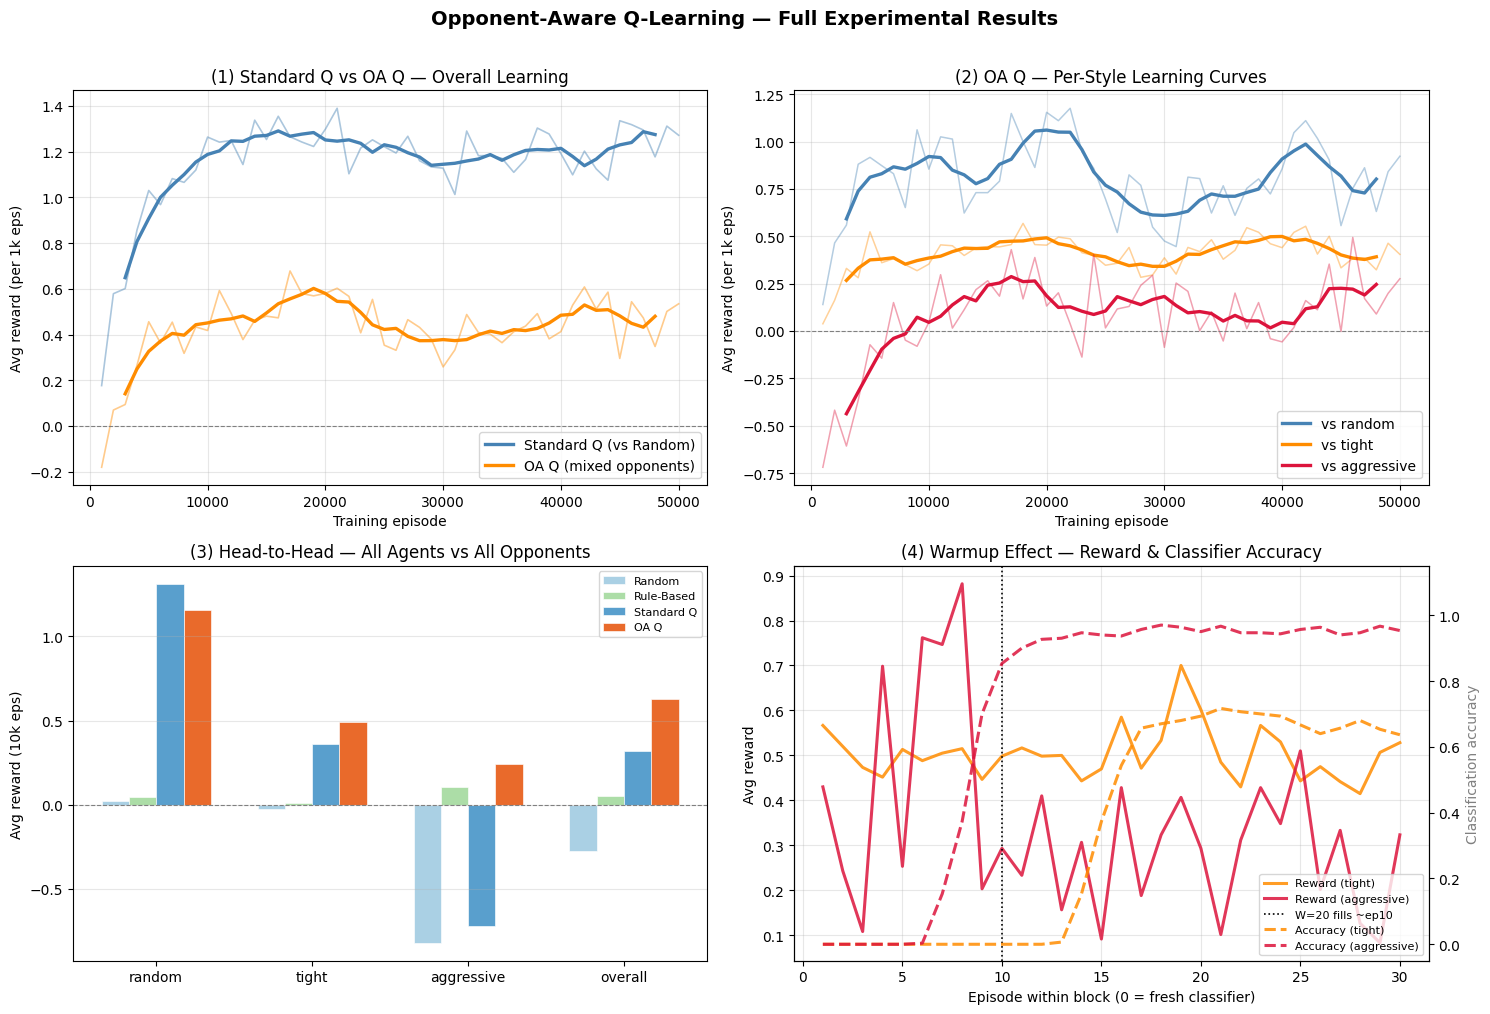

Figure saved to results.png


In [5]:
# ── Load pre-computed data ─────────────────────────────────────────────
with open('curves.json') as f:
    cd = json.load(f)
std_curve = cd['std_curve']           # list of [episode, avg_reward]
oa_curves = cd['oa_curves']           # dict: style -> list of [ep, avg]

with open('results.json') as f:
    rd = json.load(f)
all_results = rd['all_results']        # dict: agent -> {opp: avg_reward}
warmup_data = rd['warmup']             # dict: opp -> {rewards, accuracy}

STYLE_COLORS = {'random': 'steelblue', 'tight': 'darkorange', 'aggressive': 'crimson'}
AGENT_COLORS = ['#9ecae1', '#a1d99b', '#4292c6', '#e6550d', '#756bb1']

def smooth(vals, w=5):
    return list(np.convolve(vals, np.ones(w)/w, mode='valid'))

# ── Build 2x2 figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Opponent-Aware Q-Learning — Full Experimental Results',
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1 (top-left): Standard Q vs OA Q overall learning curves ─────
ax = axes[0][0]
eps_s  = [p[0] for p in std_curve]
avgs_s = [p[1] for p in std_curve]
ax.plot(eps_s, avgs_s, color='steelblue', lw=1.2, alpha=0.45)
sm = smooth(avgs_s)
ax.plot(eps_s[2:2+len(sm)], sm, color='steelblue', lw=2.4,
        label='Standard Q (vs Random)')

# OA overall = mean across three style sub-curves at each episode
oa_by_ep = defaultdict(list)
for style, data in oa_curves.items():
    for ep, val in data:
        oa_by_ep[ep].append(val)
oa_eps  = sorted(oa_by_ep)
oa_avgs = [float(np.mean(oa_by_ep[e])) for e in oa_eps]
ax.plot(oa_eps, oa_avgs, color='darkorange', lw=1.2, alpha=0.45)
sm2 = smooth(oa_avgs)
ax.plot(oa_eps[2:2+len(sm2)], sm2, color='darkorange', lw=2.4,
        label='OA Q (mixed opponents)')
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Training episode'); ax.set_ylabel('Avg reward (per 1k eps)')
ax.set_title('(1) Standard Q vs OA Q — Overall Learning')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Plot 2 (top-right): OA Q per-style learning curves ────────────────
ax = axes[0][1]
for style, data in oa_curves.items():
    eps  = [p[0] for p in data]
    avgs = [p[1] for p in data]
    col  = STYLE_COLORS.get(style, 'grey')
    ax.plot(eps, avgs, color=col, lw=1.1, alpha=0.4)
    sm = smooth(avgs)
    ax.plot(eps[2:2+len(sm)], sm, color=col, lw=2.4, label=f'vs {style}')
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Training episode'); ax.set_ylabel('Avg reward (per 1k eps)')
ax.set_title('(2) OA Q — Per-Style Learning Curves')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Plot 3 (bottom-left): Head-to-head grouped bar chart ──────────────
ax      = axes[1][0]
agents  = [k for k in ['Random','Rule-Based','Standard Q','OA Q','CFR']
           if k in all_results]
opp_labels = ['random', 'tight', 'aggressive', 'overall']
x       = np.arange(len(opp_labels))
n_ag    = len(agents)
w       = 0.7 / n_ag
for i, aname in enumerate(agents):
    vals   = [all_results[aname].get(k, 0.0) for k in opp_labels]
    offset = (i - n_ag/2 + 0.5) * w
    ax.bar(x + offset, vals, w, label=aname,
           color=AGENT_COLORS[i % len(AGENT_COLORS)], alpha=0.88,
           edgecolor='white', lw=0.5)
ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(opp_labels)
ax.set_ylabel('Avg reward (10k eps)')
ax.set_title('(3) Head-to-Head — All Agents vs All Opponents')
ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

# ── Plot 4 (bottom-right): Warmup effect — accuracy S-curve + reward ──
ax   = axes[1][1]
ax2  = ax.twinx()
positions = list(range(1, len(warmup_data['aggressive']['rewards']) + 1))
for opp_name, col in [('tight', 'darkorange'), ('aggressive', 'crimson')]:
    wd  = warmup_data[opp_name]
    acc = wd['accuracy']
    rew = wd['rewards']
    ax2.plot(positions, acc, color=col, lw=2.2, ls='--', alpha=0.85,
             label=f'Accuracy ({opp_name})')
    ax.plot(positions, rew, color=col, lw=2.2, alpha=0.85,
            label=f'Reward ({opp_name})')
ax.axvline(x=10, color='black', ls=':', lw=1.2, label='W=20 fills ~ep10')
ax.set_xlabel('Episode within block (0 = fresh classifier)')
ax.set_ylabel('Avg reward', color='black')
ax2.set_ylabel('Classification accuracy', color='grey')
ax2.set_ylim(-0.05, 1.15)
ax.set_title('(4) Warmup Effect — Reward & Classifier Accuracy')
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to results.png')

---
## Cell Block 6 — Final Summary Table & Key Findings

In [6]:

# ── Print results table ───────────────────────────────────────────────
agents_order = ['Random', 'Rule-Based', 'Standard Q', 'OA Q', 'CFR']
cols         = ['random', 'tight', 'aggressive', 'overall']
agents_avail = [a for a in agents_order if a in all_results]

col_w = 14
header = f'  {"Agent":<16s}' + ''.join(f'  {"vs "+c:>{col_w}s}' for c in cols)
print('=' * len(header))
print('  FINAL RESULTS TABLE  (avg reward over 10,000 episodes)')
print('=' * len(header))
print(header)
print('  ' + '-' * (len(header) - 2))
for aname in agents_avail:
    row = f'  {aname:<16s}'
    for c in cols:
        v = all_results[aname].get(c, float('nan'))
        row += '  ' + format(v, f'+{col_w}.4f')   # sign before width
    print(row)
print('=' * len(header))
print()

# ── Three key takeaways ───────────────────────────────────────────────
oa = all_results.get('OA Q', {})
sq = all_results.get('Standard Q', {})

delta_agg  = oa.get('aggressive', 0) - sq.get('aggressive', 0)
delta_rand = oa.get('random',     0) - sq.get('random',     0)

w_start = warmup_data['aggressive']['accuracy'][0]
w_end   = warmup_data['aggressive']['accuracy'][-1]

print('KEY FINDINGS')
print('-' * 60)
print(f'  1. MAIN RESULT    OA Q gains {delta_agg:+.4f} vs aggressive '
      f'(Std Q loses at {sq.get("aggressive",0):+.4f}; OA Q wins at '
      f'{oa.get("aggressive",0):+.4f}).')
print()
print(f'  2. DIVERSITY COST OA Q gives back {abs(delta_rand):.4f} vs random '
      f'because it trained on all three styles (1/3 random exposure) '
      f'while Standard Q trained exclusively on random.')
print()
print(f'  3. W=20 WARMUP    In short-episode games like Leduc (1-3 actions/ep), '
      f'the W=20 window must span multiple episodes. '
      f'Block-based training (30 eps/opponent) is required: '
      f'accuracy rises from {w_start:.0%} at ep-1 to {w_end:.0%} at ep-30.')
print('-' * 60)


  FINAL RESULTS TABLE  (avg reward over 10,000 episodes)
  Agent                  vs random        vs tight   vs aggressive      vs overall
  --------------------------------------------------------------------------------
  Random                   +0.0200         -0.0238         -0.8196         -0.2745
  Rule-Based               +0.0452         +0.0102         +0.1084         +0.0546
  Standard Q               +1.3130         +0.3590         -0.7204         +0.3172
  OA Q                     +1.1601         +0.4914         +0.2401         +0.6305

KEY FINDINGS
------------------------------------------------------------
  1. MAIN RESULT    OA Q gains +0.9604 vs aggressive (Std Q loses at -0.7204; OA Q wins at +0.2401).

  2. DIVERSITY COST OA Q gives back 0.1529 vs random because it trained on all three styles (1/3 random exposure) while Standard Q trained exclusively on random.

  3. W=20 WARMUP    In short-episode games like Leduc (1-3 actions/ep), the W=20 window must span multipl